In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "Data"
    / "processed"
    / "imd_temperature_2010_2025.parquet"
)

df = pd.read_parquet(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (2074620, 4)


,date,latitude,longitude,max_temperature
0,2010-01-01,8.5,73.5,32.869999
1,2010-01-01,8.5,76.5,31.040001
2,2010-01-01,8.5,77.5,32.040001
3,2010-01-01,8.5,78.5,31.110001
4,2010-01-01,9.5,76.5,31.270000


In [2]:
df = df.sort_values(
    ["latitude", "longitude", "date"]
).reset_index(drop=True)

In [3]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_year"] = df["date"].dt.dayofyear
df["month_sin"] = np.sin(
    2 * np.pi * df["day_of_year"] / 365.25
)

df["month_cos"] = np.cos(
    2 * np.pi * df["day_of_year"] / 365.25
)

In [4]:
df["latitude"] = df["latitude"].astype(float)
df["longitude"] = df["longitude"].astype(float)

In [5]:
group_cols = ["latitude", "longitude"]

df["temp_lag_1"] = (
    df.groupby(group_cols)["max_temperature"]
      .shift(1)
)

df["temp_lag_2"] = (
    df.groupby(group_cols)["max_temperature"]
      .shift(2)
)

df["temp_lag_3"] = (
    df.groupby(group_cols)["max_temperature"]
      .shift(3)
)

df["temp_lag_7"] = (
    df.groupby(group_cols)["max_temperature"]
      .shift(7)
)

In [6]:
df["temp_rolling_mean_3"] = (
    df.groupby(group_cols)["max_temperature"]
      .transform(
          lambda x: x.shift(1).rolling(3).mean()
      )
)

df["temp_rolling_mean_7"] = (
    df.groupby(group_cols)["max_temperature"]
      .transform(
          lambda x: x.shift(1).rolling(7).mean()
      )
)

df["temp_rolling_std_7"] = (
    df.groupby(group_cols)["max_temperature"]
      .transform(
          lambda x: x.shift(1).rolling(7).std()
      )
)

In [7]:
df["temperature_change_1d"] = (
    df["temp_lag_1"] - df["temp_lag_2"]
)

df["temperature_change_3d"] = (
    df["temp_lag_1"] - df["temp_lag_3"]
)

In [8]:
location_thresholds = (
    df.groupby(group_cols)["max_temperature"]
      .quantile([0.90, 0.95, 0.99])
      .unstack()
      .reset_index()
)

location_thresholds.columns = [
    "latitude",
    "longitude",
    "p90_temperature",
    "p95_temperature",
    "p99_temperature"
]

location_thresholds.head()

,latitude,longitude,p90_temperature,p95_temperature,p99_temperature
0,8.5,73.5,34.336103,34.857802,35.694044
1,8.5,76.5,33.397053,33.911174,34.706618
2,8.5,77.5,35.299999,35.869999,36.637178
3,8.5,78.5,35.723008,36.248026,36.947896
4,9.5,76.5,33.962192,34.484395,35.368598


In [9]:
df = df.merge(
    location_thresholds,
    on=group_cols,
    how="left"
)

In [10]:
monthly_baseline = (
    df.groupby(
        ["latitude", "longitude", "month"]
    )["max_temperature"]
    .mean()
    .reset_index(name="monthly_baseline")
)
df = df.merge(
    monthly_baseline,
    on=["latitude", "longitude", "month"],
    how="left"
)

In [11]:
df["temperature_anomaly"] = (
    df["max_temperature"]
    - df["monthly_baseline"]
)

In [12]:
df["anomaly_lag_1"] = (
    df["temp_lag_1"]
    - df["monthly_baseline"]
)

In [13]:
df["extreme_heat"] = (
    df["max_temperature"] > df["p95_temperature"]
)
df["not_extreme"] = (~df["extreme_heat"]).astype(int)

df["streak_group"] = (
    df.groupby(group_cols)["not_extreme"]
      .cumsum()
)

In [14]:
df["extreme_heat_streak"] = (
    df.groupby(
        group_cols + ["streak_group"]
    )["extreme_heat"]
    .transform("sum")
)

df.loc[
    ~df["extreme_heat"],
    "extreme_heat_streak"
] = 0

In [16]:
df["target_temperature"] = (
    df.groupby(group_cols)["max_temperature"]
      .shift(-1)
)

In [17]:
df["target_heatwave"] = (
    df["target_temperature"]
    > df["p95_temperature"]
).astype("Int64")

In [18]:
df["target_severity"] = np.select(
    [
        df["target_temperature"] < df["p90_temperature"],

        (
            (df["target_temperature"] >= df["p90_temperature"]) &
            (df["target_temperature"] < df["p95_temperature"])
        ),

        (
            (df["target_temperature"] >= df["p95_temperature"]) &
            (df["target_temperature"] < df["p99_temperature"])
        ),

        df["target_temperature"] >= df["p99_temperature"]
    ],
    [
        0,
        1,
        2,
        3
    ],
    default=np.nan
)

In [19]:
features = [
    "latitude",
    "longitude",

    "month",
    "day_of_year",
    "month_sin",
    "month_cos",

    "temp_lag_1",
    "temp_lag_2",
    "temp_lag_3",
    "temp_lag_7",

    "temp_rolling_mean_3",
    "temp_rolling_mean_7",
    "temp_rolling_std_7",

    "temperature_change_1d",
    "temperature_change_3d",

    "anomaly_lag_1",

    "extreme_heat_streak"
]

In [20]:
classification_features = features + [
    "p90_temperature",
    "p95_temperature",
    "p99_temperature"
]

In [21]:
forecast_df = df[
    features + ["target_temperature"]
].copy()

forecast_df = forecast_df.dropna(
    subset=features + ["target_temperature"]
)

print("Forecast dataset:", forecast_df.shape)

Forecast dataset: (2056547, 18)


In [22]:
heatwave_df = df[
    classification_features + ["target_heatwave"]
].copy()

heatwave_df = heatwave_df.dropna(
    subset=classification_features + ["target_heatwave"]
)

print("Heatwave dataset:", heatwave_df.shape)

Heatwave dataset: (2058274, 21)


In [23]:
severity_df = df[
    classification_features + ["target_severity"]
].copy()

severity_df = severity_df.dropna(
    subset=classification_features + ["target_severity"]
)

print("Severity dataset:", severity_df.shape)

Severity dataset: (2056547, 21)


In [24]:
print(
    heatwave_df["target_heatwave"]
    .value_counts()
    .sort_index()
)

print(
    heatwave_df["target_heatwave"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

target_heatwave
0    1954953
1     103321
Name: count, dtype: Int64
target_heatwave
0    94.980212
1     5.019788
Name: proportion, dtype: Float64


In [25]:
print(
    severity_df["target_severity"]
    .value_counts()
    .sort_index()
)

print(
    severity_df["target_severity"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

target_severity
0.0    1850230
1.0     102929
2.0      82591
3.0      20797
Name: count, dtype: int64
target_severity
0.0    89.967796
1.0     5.004943
2.0     4.016004
3.0     1.011258
Name: proportion, dtype: float64


In [26]:
OUTPUT_DIR = PROJECT_ROOT / "Data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

forecast_df.to_parquet(
    OUTPUT_DIR / "temperature_forecasting.parquet",
    index=False
)

heatwave_df.to_parquet(
    OUTPUT_DIR / "heatwave_prediction.parquet",
    index=False
)

severity_df.to_parquet(
    OUTPUT_DIR / "heatwave_severity.parquet",
    index=False
)

print("Datasets saved successfully.")

Datasets saved successfully.


In [27]:
df["target_heatwave"] = np.where(
    df["target_temperature"].isna(),
    np.nan,
    (
        df["target_temperature"] > df["p95_temperature"]
    ).astype(int)
)

df["target_heatwave"] = df["target_heatwave"].astype("Int64")

In [28]:
heatwave_df = df[
    classification_features + ["target_heatwave"]
].copy()

heatwave_df = heatwave_df.dropna(
    subset=classification_features + ["target_heatwave"]
)

print("Heatwave dataset:", heatwave_df.shape)

print(
    heatwave_df["target_heatwave"]
    .value_counts()
    .sort_index()
)

print(
    heatwave_df["target_heatwave"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

Heatwave dataset: (2056547, 21)
target_heatwave
0    1953226
1     103321
Name: count, dtype: Int64
target_heatwave
0    94.975996
1     5.024004
Name: proportion, dtype: Float64


In [30]:
heatwave_df.to_parquet(
    OUTPUT_DIR / "heatwave_prediction.parquet1",
    index=False
)

In [31]:
p975 = (
    df.groupby(["latitude", "longitude"])["max_temperature"]
      .quantile(0.975)
      .reset_index(name="p975_temperature")
)

df = df.merge(
    p975,
    on=["latitude", "longitude"],
    how="left"
)

In [32]:
df["target_severity"] = np.select(
    [
        df["target_temperature"] < df["p95_temperature"],

        (
            (df["target_temperature"] >= df["p95_temperature"]) &
            (df["target_temperature"] < df["p975_temperature"])
        ),

        (
            (df["target_temperature"] >= df["p975_temperature"]) &
            (df["target_temperature"] < df["p99_temperature"])
        ),

        df["target_temperature"] >= df["p99_temperature"]
    ],
    [
        0,  # Normal
        1,  # Moderate
        2,  # High
        3   # Extreme
    ],
    default=np.nan
)

In [33]:
severity_features = classification_features + [
    "p975_temperature"
]

severity_df = df[
    severity_features + ["target_severity"]
].copy()

severity_df = severity_df.dropna(
    subset=severity_features + ["target_severity"]
)

print("Severity dataset:", severity_df.shape)

Severity dataset: (2056547, 22)


In [34]:
severity_counts = (
    severity_df["target_severity"]
    .value_counts()
    .sort_index()
)

severity_percentage = (
    severity_df["target_severity"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

print("Counts:")
print(severity_counts)

print("\nPercentage:")
print(severity_percentage)

Counts:
target_severity
0.0    1953159
1.0      51534
2.0      31057
3.0      20797
Name: count, dtype: int64

Percentage:
target_severity
0.0    94.972738
1.0     2.505851
2.0     1.510153
3.0     1.011258
Name: proportion, dtype: float64


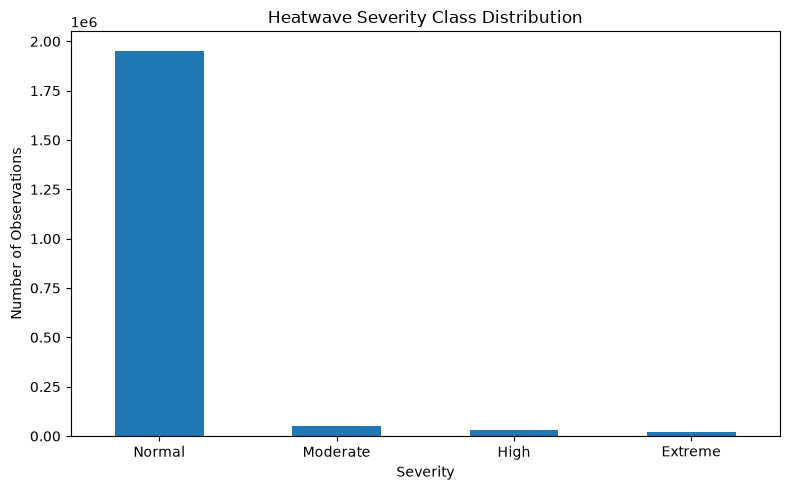

In [37]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

severity_counts.plot(kind="bar")

plt.title("Heatwave Severity Class Distribution")
plt.xlabel("Severity")
plt.ylabel("Number of Observations")

plt.xticks(
    ticks=[0, 1, 2, 3],
    labels=["Normal", "Moderate", "High", "Extreme"],
    rotation=0
)

plt.tight_layout()
plt.show()

In [38]:
severity_features = classification_features + [
    "p975_temperature"
]

severity_df = df[
    severity_features + ["target_severity"]
].copy()

# Remove rows where features/target are unavailable
severity_df = severity_df.dropna(
    subset=severity_features + ["target_severity"]
)

# Keep only extreme-heat observations
severity_df = severity_df[
    severity_df["target_severity"] > 0
].copy()

print("Severity dataset:", severity_df.shape)

Severity dataset: (103388, 22)


In [39]:
severity_counts = (
    severity_df["target_severity"]
    .value_counts()
    .sort_index()
)

severity_percentage = (
    severity_df["target_severity"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

print("Counts:")
print(severity_counts)

print("\nPercentage:")
print(severity_percentage)

Counts:
target_severity
1.0    51534
2.0    31057
3.0    20797
Name: count, dtype: int64

Percentage:
target_severity
1.0    49.845243
2.0    30.039270
3.0    20.115487
Name: proportion, dtype: float64


In [40]:
severity_df["severity_label"] = (
    severity_df["target_severity"]
    .map({
        1: "Moderate",
        2: "High",
        3: "Extreme"
    })
)

severity_df["severity_label"].value_counts()

severity_label
Moderate    51534
High        31057
Extreme     20797
Name: count, dtype: int64

In [49]:
everity_features = classification_features + [
    "p975_temperature"
]

severity_df = df[ ['date'] + 
    severity_features + ["target_severity"] 
].copy()

# Remove rows where features/target are unavailable
severity_df = severity_df.dropna(
    subset=severity_features + ["target_severity"]
)

# Keep only extreme-heat observations
severity_df = severity_df[
    severity_df["target_severity"] > 0
].copy()

print("Severity dataset:", severity_df.shape)

Severity dataset: (103388, 23)


In [50]:

severity_df.to_parquet(
    OUTPUT_DIR / "heatwave_severity.parquet1",
    index=False
)

In [42]:
heatwave_df = df[
    ["date"] + classification_features + ["target_heatwave"]
].copy()

heatwave_df = heatwave_df.dropna(
    subset=classification_features + ["target_heatwave"]
)

print(heatwave_df.shape)
print(heatwave_df["date"].min())
print(heatwave_df["date"].max())

(2056547, 22)
2010-01-08 00:00:00
2025-12-30 00:00:00


In [45]:
heatwave_df.to_parquet(
    OUTPUT_DIR / "heatwave_prediction.parquet1",
    index=False
)

0         2010-01-01
1         2010-01-02
2         2010-01-03
3         2010-01-04
4         2010-01-05
             ...    
2074615   2025-12-27
2074616   2025-12-28
2074617   2025-12-29
2074618   2025-12-30
2074619   2025-12-31
Name: date, Length: 2074620, dtype: datetime64[us]

In [47]:
severity_df = df[
    ['date'] 
].copy()

In [48]:
severity_df.columns

Index(['date'], dtype='str')

In [52]:
regression_features = [
    "latitude",
    "longitude",
    "month",
    "day_of_year",
    "month_sin",
    "month_cos",
    "max_temperature",
    "temp_lag_1",
    "temp_lag_2",
    "temp_lag_3",
    "temp_lag_7",
    "temp_rolling_mean_3",
    "temp_rolling_mean_7",
    "temp_rolling_std_7",
    "temperature_change_1d",
    "temperature_change_3d",
    "temperature_anomaly",
    "anomaly_lag_1",
    "extreme_heat_streak",
    "p90_temperature",
    "p95_temperature",
    "p975_temperature",
    "p99_temperature"
]

regression_df = df[
    ["date"] + regression_features + ["target_temperature"]
].dropna(
    subset=regression_features + ["target_temperature"]
).copy()

print(regression_df.shape)
print(regression_df.head())

(2055334, 25)
         date  latitude  longitude  month  day_of_year  month_sin  month_cos  \
7  2010-01-08       8.5       73.5      1            8   0.137185   0.990545   
8  2010-01-09       8.5       73.5      1            9   0.154204   0.988039   
9  2010-01-10       8.5       73.5      1           10   0.171177   0.985240   
10 2010-01-11       8.5       73.5      1           11   0.188099   0.982150   
11 2010-01-12       8.5       73.5      1           12   0.204966   0.978769   

    max_temperature  temp_lag_1  temp_lag_2  ...  temperature_change_1d  \
7         32.320000   32.259998   32.270000  ...              -0.010002   
8         32.669998   32.320000   32.259998  ...               0.060001   
9         29.540001   32.669998   32.320000  ...               0.349998   
10        32.250000   29.540001   32.669998  ...              -3.129997   
11        32.349998   32.250000   29.540001  ...               2.709999   

    temperature_change_3d  temperature_anomaly  anomal

In [53]:
regression_df.to_parquet(
    "../Data/processed/temperature_regression.parquet",
    index=False
)